# JOCN Benchmark 2024 v2 Plots

Replicates the legacy JOCN plot families using v2 result CSVs.

In [ ]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'src' / 'optical_networking_gym_v2').exists():
    REPO_ROOT = next(path for path in Path.cwd().parents if (path / 'src' / 'optical_networking_gym_v2').exists())
sys.path.insert(0, str(REPO_ROOT / 'src'))

from optical_networking_gym_v2 import build_scenario
from optical_networking_gym_v2.defaults import resolve_topology
from optical_networking_gym_v2.network.topology import TopologyModel, _read_sndlib_topology

plt.rcParams.update({'font.size': 14})

SCRIPT_DIR = Path.cwd()
if SCRIPT_DIR.name != 'JOCN_Benchmark_2024':
    SCRIPT_DIR = Path('examples/JOCN_Benchmark_2024').resolve()
RESULTS_DIR = SCRIPT_DIR / 'results'
FAMILY = 'JOCN_Benchmark_2024'
TOPOLOGY_ID = 'nobel-eu'
POLICY_LABELS = ['KSP-FF-BM', 'LS-BM-KSP', 'BM-KSP-LB', 'KSP-LB-BM']

def latest_run(script_stem):
    root = RESULTS_DIR / FAMILY / script_stem
    runs = sorted(path for path in root.iterdir() if path.is_dir())
    if not runs:
        raise FileNotFoundError(f'No runs found under {root}')
    return runs[-1]

def read_artifacts(script_stem):
    run = latest_run(script_stem)
    data = {
        'run_dir': run,
        'episodes': pd.read_csv(run / 'episodes.csv'),
        'summary': pd.read_csv(run / 'summary.csv'),
    }
    services_path = run / 'services.csv'
    data['services'] = pd.read_csv(services_path) if services_path.exists() else pd.DataFrame()
    return data

def show_fig(fig):
    fig.tight_layout()
    plt.show()

def legacy_path_length_scale(values):
    series = pd.to_numeric(values, errors='coerce')
    return series / 1000.0 if series.max(skipna=True) > 10000 else series

scenario = build_scenario('jocn_benchmark')
scenario_parameters = {
    'scenario_id': scenario.scenario_id,
    'topology_id': scenario.topology_id,
    'k_paths': scenario.k_paths,
    'num_spectrum_resources': scenario.num_spectrum_resources,
    'episode_length': scenario.episode_length,
    'load': scenario.load,
    'mean_holding_time': scenario.mean_holding_time,
    'qot_constraint': scenario.qot_constraint,
    'launch_power_dbm': scenario.launch_power_dbm,
    'margin': scenario.margin,
    'bit_rates': scenario.bit_rates,
    'modulations_to_consider': scenario.modulations_to_consider,
    'modulations': [(m.name, m.maximum_length, m.spectral_efficiency, m.minimum_osnr, m.inband_xt) for m in scenario.modulations],
    'attenuation_db_per_km': scenario.default_attenuation_db_per_km,
    'noise_figure_db': scenario.default_noise_figure_db,
    'frequency_start': scenario.frequency_start,
    'slot_bw': scenario.frequency_slot_bandwidth,
    'bandwidth': scenario.bandwidth,
    'seed': scenario.seed,
}
print(json.dumps(scenario_parameters, indent=2))

{
  "scenario_id": "jocn_benchmark",
  "topology_id": "nobel-eu",
  "k_paths": 5,
  "num_spectrum_resources": 320,
  "episode_length": 1000,
  "load": 210.0,
  "mean_holding_time": 10800.0,
  "qot_constraint": "ASE+NLI",
  "launch_power_dbm": -4.0,
  "margin": 0.0,
  "bit_rates": [
    10,
    40,
    100,
    400
  ],
  "modulations_to_consider": 6,
  "modulations": [
    [
      "BPSK",
      100000.0,
      1,
      3.71,
      -14.0
    ],
    [
      "QPSK",
      2000.0,
      2,
      6.72,
      -17.0
    ],
    [
      "8QAM",
      1000.0,
      3,
      10.84,
      -20.0
    ],
    [
      "16QAM",
      500.0,
      4,
      13.24,
      -23.0
    ],
    [
      "32QAM",
      250.0,
      5,
      16.16,
      -26.0
    ],
    [
      "64QAM",
      125.0,
      6,
      19.01,
      -29.0
    ]
  ],
  "attenuation_db_per_km": 0.2,
  "noise_figure_db": 4.5,
  "frequency_start": 191693290734824.28,
  "slot_bw": 12500000000.0,
  "bandwidth": 4000000000000.0,
  "seed": 10
}


## Topology

nodes: 28 378
edges: 41


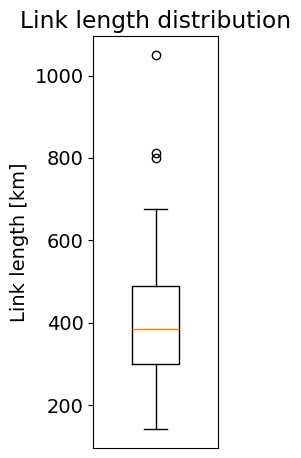

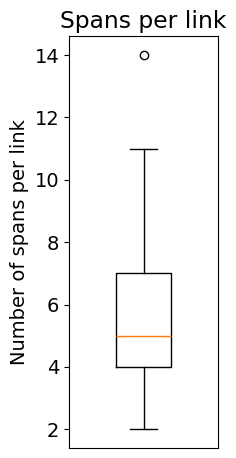

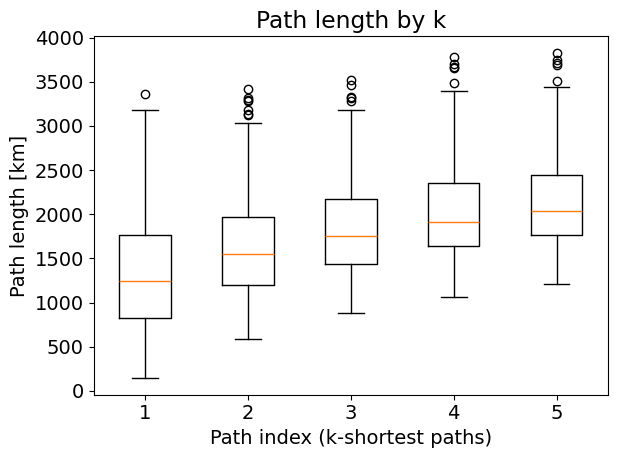

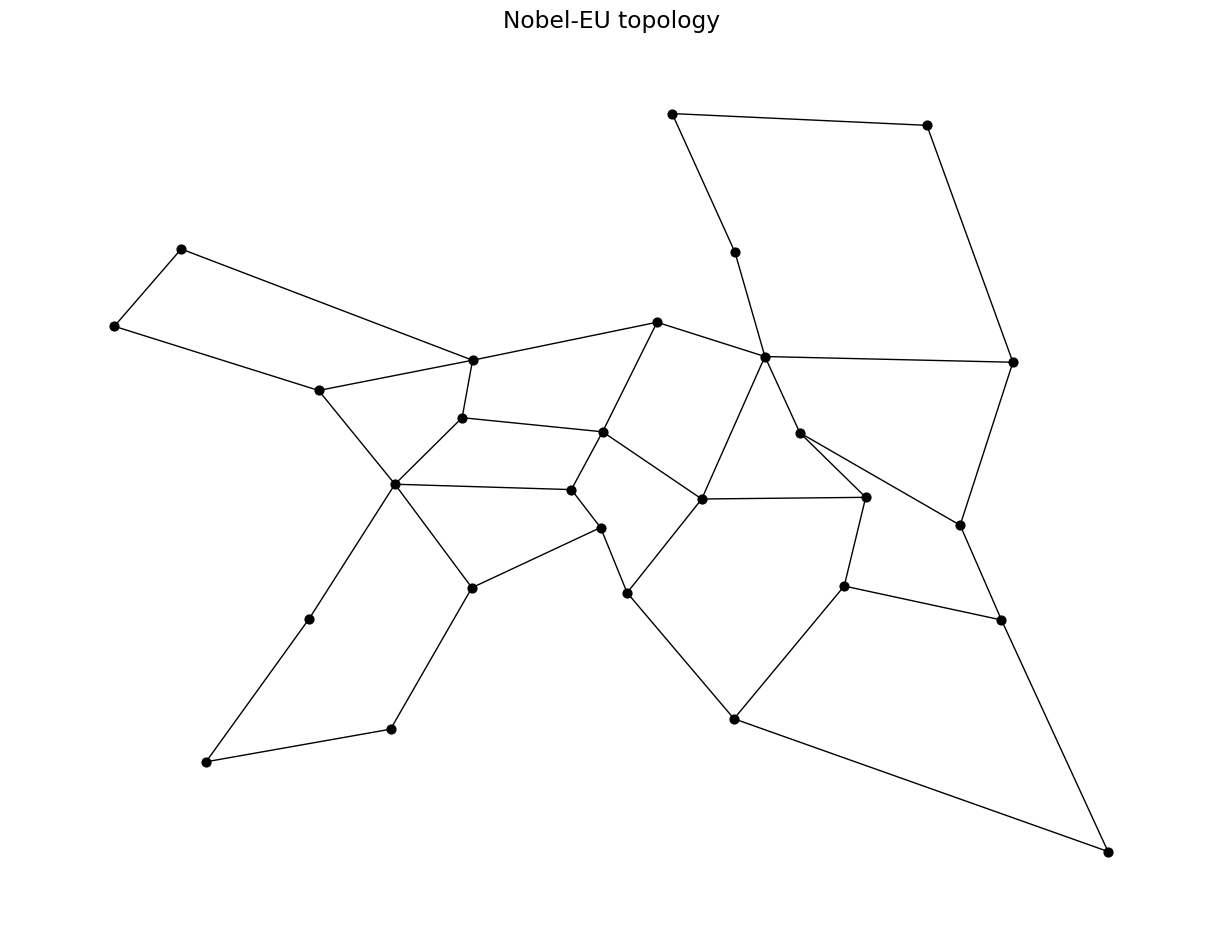

In [ ]:
topology_path = resolve_topology(TOPOLOGY_ID)
topology = TopologyModel.from_file(
    topology_path,
    topology_id=TOPOLOGY_ID,
    k_paths=scenario.k_paths,
    max_span_length_km=scenario.max_span_length_km,
    default_attenuation_db_per_km=scenario.default_attenuation_db_per_km,
    default_noise_figure_db=scenario.default_noise_figure_db,
)
print('nodes:', len(topology.node_names), len(topology.node_names) * (len(topology.node_names) - 1) // 2)
print('edges:', topology.link_count)

fig, ax = plt.subplots(figsize=(2.5, 4.8))
ax.boxplot([link.length_km for link in topology.links])
ax.set_title('Link length distribution')
ax.set_ylabel('Link length [km]')
ax.set_xticks([])
ax.set_xlim([0.8, 1.2])
show_fig(fig)

fig, ax = plt.subplots(figsize=(2.5, 4.8))
ax.boxplot([len(link.spans) for link in topology.links])
ax.set_title('Spans per link')
ax.set_ylabel('Number of spans per link')
ax.set_xticks([])
ax.set_xlim([0.8, 1.2])
show_fig(fig)

path_lengths = []
for k_index in range(5):
    values = [path.length_km for path in topology.paths if path.k == k_index]
    if values:
        path_lengths.append(values)
fig, ax = plt.subplots()
ax.boxplot(path_lengths)
ax.set_title('Path length by k')
ax.set_xlabel('Path index (k-shortest paths)')
ax.set_ylabel('Path length [km]')
show_fig(fig)

graph = _read_sndlib_topology(topology_path)
pos = nx.get_node_attributes(graph, 'pos')
fig, ax = plt.subplots(figsize=(12.8, 9.6))
nx.draw_networkx_nodes(graph, pos=pos, node_color='black', node_size=40, ax=ax)
nx.draw_networkx_edges(graph, pos=pos, ax=ax)
ax.set_title('Nobel-EU topology')
ax.axis('off')
ax.set_aspect('equal', adjustable='box')
show_fig(fig)

## Launch Power

launch power run: D:\mestrado\optical-networking-gym\optical_networking_gym_v2\examples\JOCN_Benchmark_2024\results\JOCN_Benchmark_2024\graph_launch_power\20260513-153222


,date,topology_id,policy,sweep_name,sweep_value,episodes,requests_per_episode,load,margin,launch_power_dbm,...,final_osnr_margin_mean_mean,final_osnr_margin_mean_std,episode_disrupted_services_count_mean,episode_disrupted_services_count_std,episode_disrupted_services_rate_mean,episode_disrupted_services_rate_std,disrupted_or_dropped_services_mean,disrupted_or_dropped_services_std,episode_time_s_mean,episode_time_s_std
0,13-05,nobel-eu,first_fit,launch_power_dbm,-8.0,10,1000,210.0,0.0,-8.0,...,1.716184,0.067416,0.0,0.0,0.0,0.0,0.0,0.0,7.802994,0.380078
1,13-05,nobel-eu,first_fit,launch_power_dbm,-6.0,10,1000,210.0,0.0,-6.0,...,2.086428,0.128000,0.0,0.0,0.0,0.0,0.0,0.0,6.129121,0.562976
2,13-05,nobel-eu,first_fit,launch_power_dbm,-4.0,10,1000,210.0,0.0,-4.0,...,2.661590,0.087438,0.0,0.0,0.0,0.0,0.0,0.0,5.526815,0.368521
3,13-05,nobel-eu,first_fit,launch_power_dbm,-2.0,10,1000,210.0,0.0,-2.0,...,2.972728,0.089992,0.0,0.0,0.0,0.0,0.0,0.0,5.574266,0.960134
4,13-05,nobel-eu,first_fit,launch_power_dbm,0.0,10,1000,210.0,0.0,0.0,...,2.483168,0.111938,0.0,0.0,0.0,0.0,0.0,0.0,4.475254,0.203979


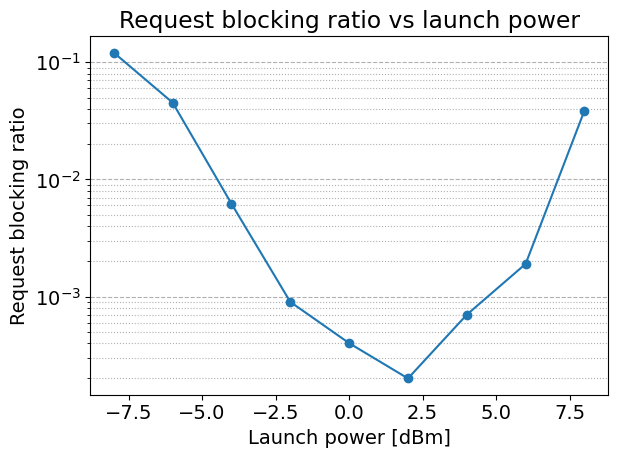

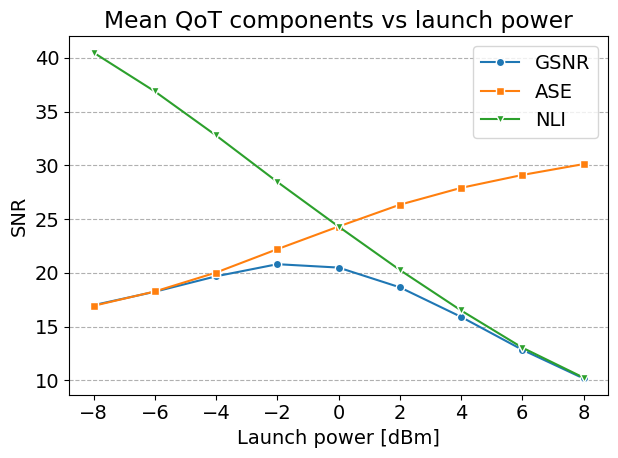

,date,topology_id,policy,sweep_name,sweep_value,load,margin,launch_power_dbm,episode_index,episode_seed,...,min_osnr,osnr,osnr_req,osnr_margin,ase,nli,disrupted_services,fragmentation_shannon_entropy,fragmentation_route_cuts,fragmentation_route_rss
count,87850,87850,87850,87850,87850.000000,87850.0,87850.0,87850.000000,87850.000000,87850.000000,...,87850.000000,87850.000000,87850.000000,87850.000000,87850.000000,87850.000000,87850.0,87850.000000,87850.000000,87850.000000
unique,1,1,1,1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,13-05,nobel-eu,first_fit,launch_power_dbm,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,87850,87850,87850,87850,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,0.107001,210.0,0.0,0.107001,4.499055,14.499055,...,14.914504,17.107073,14.914504,2.192568,24.011484,24.558375,0.0,0.545489,5.783658,0.619804
std,NaN,NaN,NaN,NaN,5.093141,0.0,0.0,5.093141,2.871346,2.871346,...,4.463039,5.039175,4.463039,1.804794,6.658334,10.873540,0.0,0.156564,2.564551,0.184776
min,NaN,NaN,NaN,NaN,-8.000000,210.0,0.0,-8.000000,0.000000,10.000000,...,3.710000,3.785307,3.710000,0.000039,0.000000,0.000000,0.0,0.000000,0.512500,0.221766
25%,NaN,NaN,NaN,NaN,-4.000000,210.0,0.0,-4.000000,2.000000,12.000000,...,13.240000,13.835751,13.240000,0.912743,19.851016,15.562799,0.0,0.478190,3.929167,0.466925
50%,NaN,NaN,NaN,NaN,0.000000,210.0,0.0,0.000000,4.000000,14.000000,...,16.160000,17.631235,16.160000,1.834672,24.235142,23.971733,0.0,0.589178,5.979166,0.600511
75%,NaN,NaN,NaN,NaN,4.000000,210.0,0.0,4.000000,7.000000,17.000000,...,19.010000,20.633145,19.010000,2.811057,28.472279,33.076595,0.0,0.651800,7.687500,0.756429


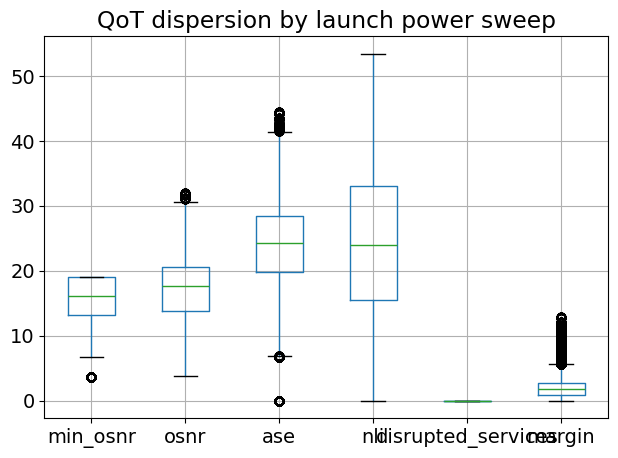

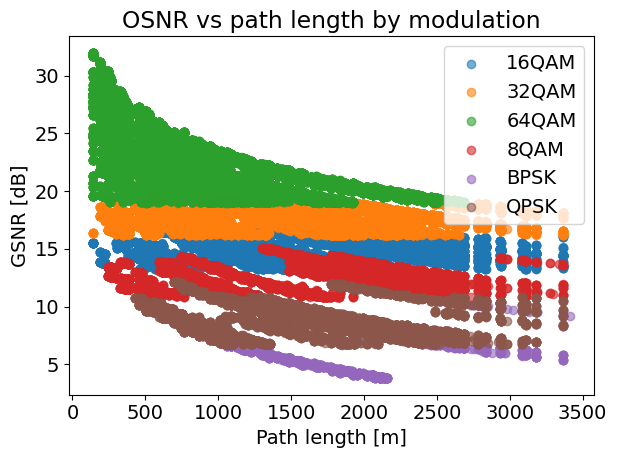

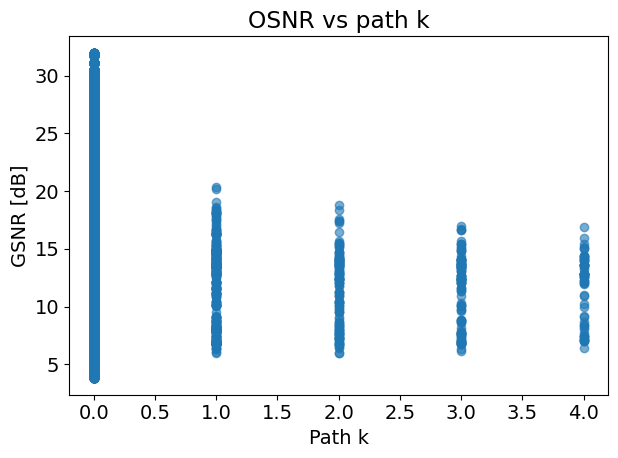

In [ ]:
launch = read_artifacts('graph_launch_power')
lp_summary = launch['summary'].sort_values('sweep_value')
lp_services = launch['services']
print('launch power run:', launch['run_dir'])
display(lp_summary.head())

fig, ax = plt.subplots()
ax.plot(lp_summary['sweep_value'], lp_summary['service_blocking_rate_mean'], marker='o')
ax.set_title('Request blocking ratio vs launch power')
ax.set_yscale('log')
ax.grid(visible=True, which='major', axis='y', ls='--')
ax.grid(visible=True, which='minor', axis='y', ls=':')
ax.set_xlabel('Launch power [dBm]')
ax.set_ylabel('Request blocking ratio')
show_fig(fig)

if not lp_services.empty:
    accepted = lp_services[lp_services['path_k'] != -1]
    grouped = accepted.groupby('launch_power_dbm')[['osnr', 'ase', 'nli', 'osnr_margin']].mean().reset_index()
    fig, ax = plt.subplots()
    for column, label, marker in [('osnr', 'GSNR', 'o'), ('ase', 'ASE', 's'), ('nli', 'NLI', 'v')]:
        ax.plot(grouped['launch_power_dbm'], grouped[column], marker=marker, mec='white', label=label)
    ax.set_title('Mean QoT components vs launch power')
    ax.set_xlabel('Launch power [dBm]')
    ax.set_ylabel('SNR')
    ax.grid(visible=True, which='major', axis='y', ls='--')
    ax.legend()
    show_fig(fig)

    display(accepted.describe(include='all'))
    fig, ax = plt.subplots()
    boxplot_columns = [column for column in ['min_osnr', 'osnr', 'ase', 'nli', 'disrupted_services', 'osnr_margin'] if column in accepted]
    accepted[boxplot_columns].rename(columns={'osnr_margin': 'margin'}).boxplot(ax=ax)
    ax.set_title('QoT dispersion by launch power sweep')
    show_fig(fig)

    fig, ax = plt.subplots()
    for modulation in sorted(accepted['modulation'].dropna().unique()):
        data = accepted[accepted['modulation'] == modulation]
        ax.scatter(legacy_path_length_scale(data['path_length']), data['osnr'], label=modulation, alpha=0.6)
    ax.set_title('OSNR vs path length by modulation')
    ax.set_xlabel('Path length [m]')
    ax.set_ylabel('GSNR [dB]')
    ax.legend()
    show_fig(fig)

    fig, ax = plt.subplots()
    ax.scatter(accepted['path_k'], accepted['osnr'], alpha=0.6)
    ax.set_title('OSNR vs path k')
    ax.set_xlabel('Path k')
    ax.set_ylabel('GSNR [dB]')
    show_fig(fig)

## Margin

margin run: D:\mestrado\optical-networking-gym\optical_networking_gym_v2\examples\JOCN_Benchmark_2024\results\JOCN_Benchmark_2024\graph_margin\20260513-172655


,date,topology_id,policy,sweep_name,sweep_value,episodes,requests_per_episode,load,margin,launch_power_dbm,...,final_osnr_margin_mean_mean,final_osnr_margin_mean_std,episode_disrupted_services_count_mean,episode_disrupted_services_count_std,episode_disrupted_services_rate_mean,episode_disrupted_services_rate_std,disrupted_or_dropped_services_mean,disrupted_or_dropped_services_std,episode_time_s_mean,episode_time_s_std
0,13-05,nobel-eu,first_fit,margin,0.0,1,1000,210.0,0.0,-4.0,...,1.748405,0.0,135.0,0.0,0.136364,0.0,0.0,0.0,25.774554,0.0
1,13-05,nobel-eu,first_fit,margin,0.5,1,1000,210.0,0.5,-4.0,...,1.625111,0.0,142.0,0.0,0.144309,0.0,0.0,0.0,25.897796,0.0
2,13-05,nobel-eu,first_fit,margin,1.0,1,1000,210.0,1.0,-4.0,...,1.408558,0.0,162.0,0.0,0.165644,0.0,0.0,0.0,25.532754,0.0
3,13-05,nobel-eu,first_fit,margin,1.5,1,1000,210.0,1.5,-4.0,...,1.314076,0.0,184.0,0.0,0.191467,0.0,0.0,0.0,27.140211,0.0
4,13-05,nobel-eu,first_fit,margin,2.0,1,1000,210.0,2.0,-4.0,...,1.136413,0.0,177.0,0.0,0.186906,0.0,0.0,0.0,27.066730,0.0


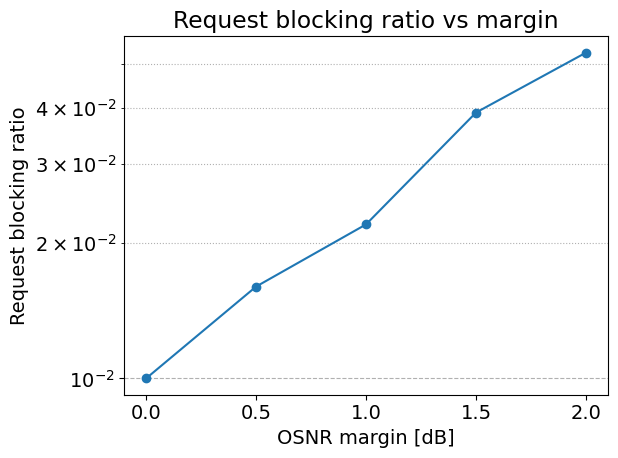

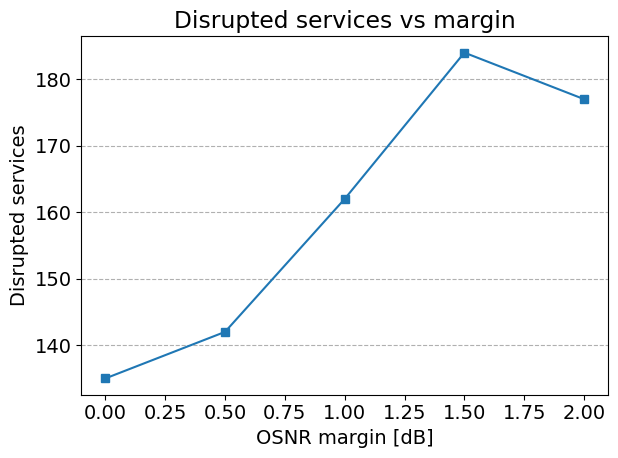

,date,topology_id,policy,sweep_name,sweep_value,load,margin,launch_power_dbm,episode_index,episode_seed,...,min_osnr,osnr,osnr_req,osnr_margin,ase,nli,disrupted_services,fragmentation_shannon_entropy,fragmentation_route_cuts,fragmentation_route_rss
count,4860,4860,4860,4860,4860.000000,4860.0,4860.000000,4860.0,4860.0,4860.0,...,4860.000000,4860.000000,4860.000000,4860.000000,4860.000000,4860.000000,4860.0,4860.000000,4860.000000,4860.000000
unique,1,1,1,1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,13-05,nobel-eu,first_fit,margin,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,4860,4860,4860,4860,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,0.988786,210.0,0.988786,-4.0,0.0,10.0,...,16.212191,18.758384,17.200977,1.557406,20.057487,28.868756,0.0,0.646159,6.263408,0.521564
std,NaN,NaN,NaN,NaN,0.706108,0.0,0.706108,0.0,0.0,0.0,...,3.759765,4.337988,3.756278,1.659573,5.283502,6.927592,0.0,0.145562,2.563620,0.174338
min,NaN,NaN,NaN,NaN,0.000000,210.0,0.000000,-4.0,0.0,10.0,...,6.720000,6.762980,6.720000,0.000002,0.000000,0.000000,0.0,0.000000,0.512500,0.266460
25%,NaN,NaN,NaN,NaN,0.500000,210.0,0.500000,-4.0,0.0,10.0,...,16.160000,16.993903,16.160000,0.362974,17.744122,24.105984,0.0,0.649310,4.612500,0.395419
50%,NaN,NaN,NaN,NaN,1.000000,210.0,1.000000,-4.0,0.0,10.0,...,19.010000,19.457417,19.010000,1.120160,21.222978,26.790245,0.0,0.700672,6.662500,0.464296
75%,NaN,NaN,NaN,NaN,1.500000,210.0,1.500000,-4.0,0.0,10.0,...,19.010000,21.344423,20.010000,2.103436,23.326043,33.272740,0.0,0.722528,8.126785,0.596012


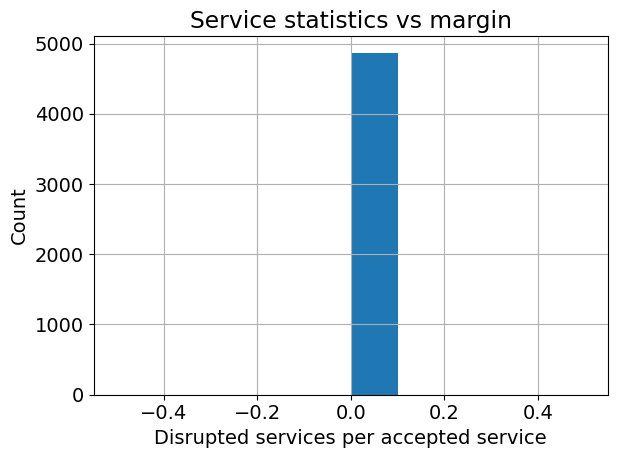

In [ ]:
margin = read_artifacts('graph_margin')
mr_summary = margin['summary'].sort_values('sweep_value')
mr_services = margin['services']
print('margin run:', margin['run_dir'])
display(mr_summary.head())

fig, ax = plt.subplots()
ax.plot(mr_summary['sweep_value'], mr_summary['service_blocking_rate_mean'], marker='o')
ax.set_title('Request blocking ratio vs margin')
ax.set_yscale('log')
ax.grid(visible=True, which='major', axis='y', ls='--')
ax.grid(visible=True, which='minor', axis='y', ls=':')
ax.set_xlabel('OSNR margin [dB]')
ax.set_ylabel('Request blocking ratio')
show_fig(fig)

fig, ax = plt.subplots()
ax.plot(mr_summary['sweep_value'], mr_summary['episode_disrupted_services_count_mean'], marker='s')
ax.set_title('Disrupted services vs margin')
ax.grid(visible=True, which='major', axis='y', ls='--')
ax.set_xlabel('OSNR margin [dB]')
ax.set_ylabel('Disrupted services')
show_fig(fig)

if not mr_services.empty:
    accepted = mr_services[mr_services['path_k'] != -1]
    display(accepted.describe(include='all'))
    fig, ax = plt.subplots()
    accepted['disrupted_services'].hist(ax=ax)
    ax.set_title('Service statistics vs margin')
    ax.set_xlabel('Disrupted services per accepted service')
    ax.set_ylabel('Count')
    show_fig(fig)

## Load

load run: D:\mestrado\optical-networking-gym\optical_networking_gym_v2\examples\JOCN_Benchmark_2024\results\JOCN_Benchmark_2024\graph_load\20260513-171024


,date,topology_id,policy,sweep_name,sweep_value,episodes,requests_per_episode,load,margin,launch_power_dbm,...,final_osnr_margin_mean_mean,final_osnr_margin_mean_std,episode_disrupted_services_count_mean,episode_disrupted_services_count_std,episode_disrupted_services_rate_mean,episode_disrupted_services_rate_std,disrupted_or_dropped_services_mean,disrupted_or_dropped_services_std,episode_time_s_mean,episode_time_s_std
0,13-05,nobel-eu,BM-KSP-LB,load,50.0,10,1000,50.0,0.0,-4.0,...,1.191110,0.168309,0.0,0.0,0.0,0.0,0.0,0.0,8.560595,0.191339
1,13-05,nobel-eu,BM-KSP-LB,load,100.0,10,1000,100.0,0.0,-4.0,...,1.185777,0.115997,0.0,0.0,0.0,0.0,0.0,0.0,6.095838,0.328827
2,13-05,nobel-eu,BM-KSP-LB,load,150.0,10,1000,150.0,0.0,-4.0,...,1.179522,0.065702,0.0,0.0,0.0,0.0,0.0,0.0,4.720372,0.198812
3,13-05,nobel-eu,BM-KSP-LB,load,200.0,10,1000,200.0,0.0,-4.0,...,1.222373,0.069017,0.0,0.0,0.0,0.0,0.0,0.0,3.945999,0.181893
4,13-05,nobel-eu,BM-KSP-LB,load,250.0,10,1000,250.0,0.0,-4.0,...,1.253963,0.075902,0.0,0.0,0.0,0.0,0.0,0.0,3.567634,0.157926


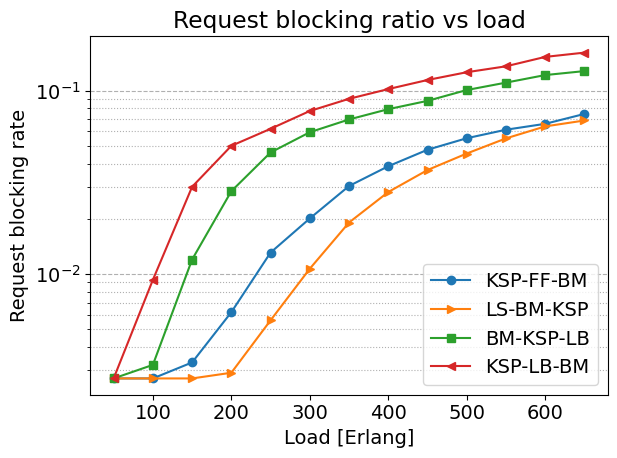

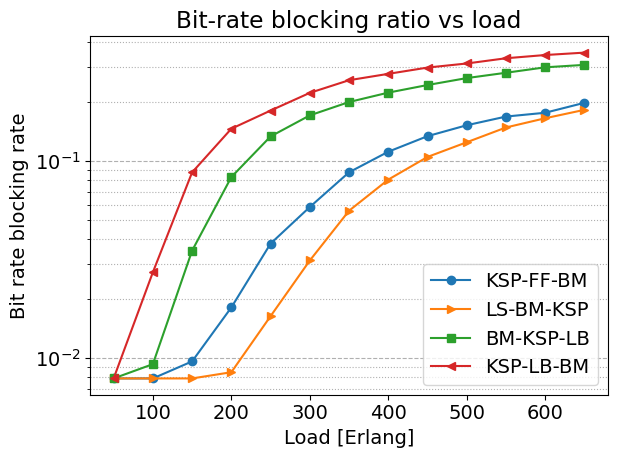

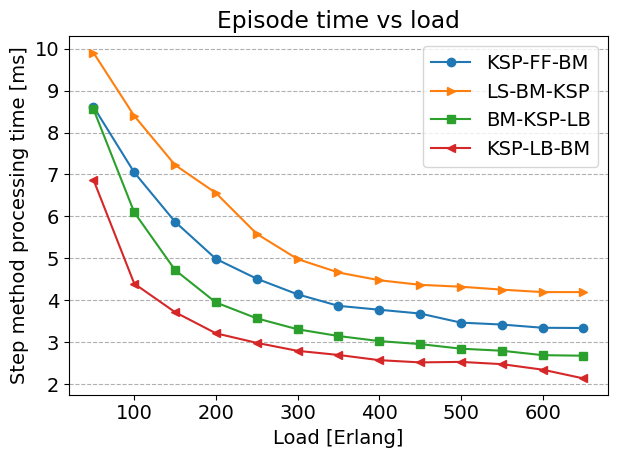

In [ ]:
load = read_artifacts('graph_load')
load_summary = load['summary'].sort_values(['policy', 'sweep_value'])
print('load run:', load['run_dir'])
display(load_summary.head())

markers = ['o', '>', 's', '<']
fig, ax = plt.subplots()
for index, policy in enumerate(POLICY_LABELS):
    data = load_summary[load_summary['policy'] == policy].sort_values('sweep_value')
    ax.plot(data['sweep_value'], data['service_blocking_rate_mean'], label=policy, marker=markers[index])
ax.set_title('Request blocking ratio vs load')
ax.set_yscale('log')
ax.grid(visible=True, which='major', axis='y', ls='--')
ax.grid(visible=True, which='minor', axis='y', ls=':')
ax.set_xlabel('Load [Erlang]')
ax.set_ylabel('Request blocking rate')
ax.legend(labels=POLICY_LABELS)
show_fig(fig)

fig, ax = plt.subplots()
for index, policy in enumerate(POLICY_LABELS):
    data = load_summary[load_summary['policy'] == policy].sort_values('sweep_value')
    ax.plot(data['sweep_value'], data['bit_rate_blocking_rate_mean'], label=policy, marker=markers[index])
ax.set_title('Bit-rate blocking ratio vs load')
ax.set_yscale('log')
ax.grid(visible=True, which='major', axis='y', ls='--')
ax.grid(visible=True, which='minor', axis='y', ls=':')
ax.set_xlabel('Load [Erlang]')
ax.set_ylabel('Bit rate blocking rate')
ax.legend(labels=POLICY_LABELS)
show_fig(fig)

fig, ax = plt.subplots()
for index, policy in enumerate(POLICY_LABELS):
    data = load_summary[load_summary['policy'] == policy].sort_values('sweep_value')
    ax.plot(data['sweep_value'], data['episode_time_s_mean'], label=policy, marker=markers[index])
ax.set_title('Episode time vs load')
ax.grid(visible=True, which='major', axis='y', ls='--')
ax.set_xlabel('Load [Erlang]')
ax.set_ylabel('Step method processing time [ms]')
ax.legend(labels=POLICY_LABELS)
show_fig(fig)